In [2]:
from pathlib import Path
import re
from collections import defaultdict

data_dir = Path("../data/signatures")
org_dir = data_dir / "full_org"
forg_dir = data_dir / "full_forg"

def count_by_writer(folder):
    counts = defaultdict(int)
    for file in folder.glob("*.png"):
        match = re.search(r"(\d+)_(\d+)", file.stem)
        if match:
            writer_id = match.group(1)
            counts[writer_id] += 1
    return counts

org_counts = count_by_writer(org_dir)
forg_counts = count_by_writer(forg_dir)

print(f"Liczba pisarzy w full_org: {len(org_counts)}")
print(f"Liczba pisarzy w full_forg: {len(forg_counts)}")

for writer_id in sorted(set(org_counts) | set(forg_counts), key=int):
    o, f = org_counts.get(writer_id, 0), forg_counts.get(writer_id, 0)
    if o != 24 or f != 24:
        print(f"Pisarz {writer_id}: oryginalne={o}, fałszerstwa={f}  <-- ODCHYLENIE")

Liczba pisarzy w full_org: 55
Liczba pisarzy w full_forg: 55


In [3]:
from PIL import Image

def analyze_images(folder, sample_limit=None):
    sizes = set()
    modes = set()
    files = list(folder.glob("*.png"))
    if sample_limit:
        files = files[:sample_limit]
    for file in files:
        with Image.open(file) as img:
            sizes.add(img.size)
            modes.add(img.mode)
    return sizes, modes

org_sizes, org_modes = analyze_images(org_dir)
forg_sizes, forg_modes = analyze_images(forg_dir)

print(f"full_org - unikalne rozmiary: {len(org_sizes)}, tryby kolorów: {org_modes}")
print(f"full_forg - unikalne rozmiary: {len(forg_sizes)}, tryby kolorów: {forg_modes}")

if len(org_sizes) <= 10:
    print("Rozmiary w full_org:", org_sizes)
if len(forg_sizes) <= 10:
    print("Rozmiary w full_forg:", forg_sizes)

full_org - unikalne rozmiary: 1095, tryby kolorów: {'RGBA', 'L'}
full_forg - unikalne rozmiary: 1006, tryby kolorów: {'P', 'RGBA'}


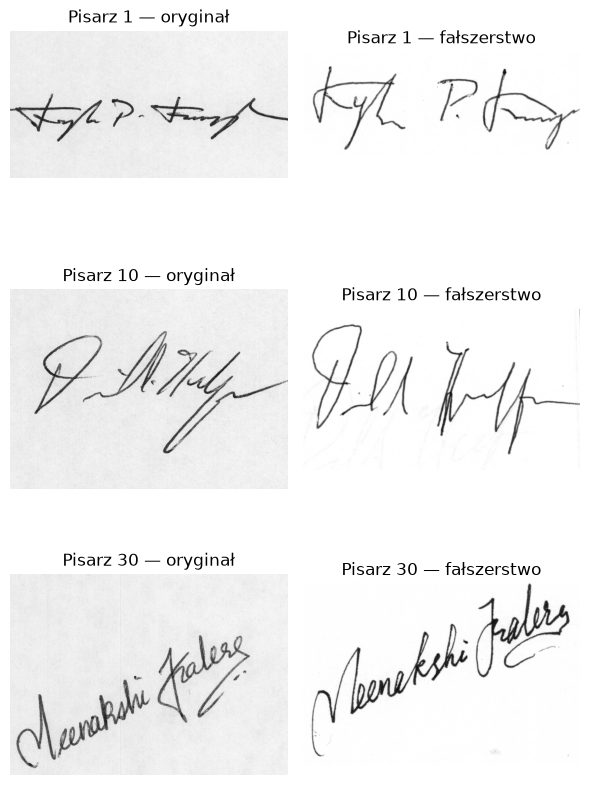

In [4]:
import matplotlib.pyplot as plt

def get_files_for_writer(folder, writer_id):
    return sorted(folder.glob(f"*{writer_id}_*.png")) or sorted(folder.glob(f"*_{writer_id}_*.png"))

writer_ids_to_show = ["1", "10", "30"]

fig, axes = plt.subplots(len(writer_ids_to_show), 2, figsize=(6, 3 * len(writer_ids_to_show)))

for row, writer_id in enumerate(writer_ids_to_show):
    org_files = get_files_for_writer(org_dir, writer_id)
    forg_files = get_files_for_writer(forg_dir, writer_id)

    org_img = Image.open(org_files[0]).convert("L")
    forg_img = Image.open(forg_files[0]).convert("L")

    axes[row, 0].imshow(org_img, cmap="gray")
    axes[row, 0].set_title(f"Pisarz {writer_id} — oryginał")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(forg_img, cmap="gray")
    axes[row, 1].set_title(f"Pisarz {writer_id} — fałszerstwo")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def pixel_stats(folder, sample_limit=None):
    files = list(folder.glob("*.png"))
    if sample_limit:
        files = files[:sample_limit]
    all_pixels = []
    for file in files:
        img = Image.open(file).convert("L")
        arr = np.array(img, dtype=np.float32) / 255.0
        all_pixels.append(arr.flatten())
    all_pixels = np.concatenate(all_pixels)
    return all_pixels.mean(), all_pixels.std()

org_mean, org_std = pixel_stats(org_dir)
forg_mean, forg_std = pixel_stats(forg_dir)

print(f"full_org  — średnia: {org_mean:.4f}, odchylenie std: {org_std:.4f}")
print(f"full_forg — średnia: {forg_mean:.4f}, odchylenie std: {forg_std:.4f}")

full_org  — średnia: 0.9251, odchylenie std: 0.0795
full_forg — średnia: 0.9754, odchylenie std: 0.0847


In [6]:
def collect_dimensions(folder):
    widths, heights = [], []
    for file in folder.glob("*.png"):
        with Image.open(file) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    return np.array(widths), np.array(heights)

org_w, org_h = collect_dimensions(org_dir)
forg_w, forg_h = collect_dimensions(forg_dir)

for name, w, h in [("full_org", org_w, org_h), ("full_forg", forg_w, forg_h)]:
    print(f"{name}:")
    print(f"  szerokość — min={w.min()}, max={w.max()}, średnia={w.mean():.0f}, mediana={np.median(w):.0f}")
    print(f"  wysokość  — min={h.min()}, max={h.max()}, średnia={h.mean():.0f}, mediana={np.median(h):.0f}")

full_org:
  szerokość — min=264, max=672, średnia=536, mediana=577
  wysokość  — min=145, max=576, średnia=356, mediana=349
full_forg:
  szerokość — min=270, max=888, średnia=552, mediana=576
  wysokość  — min=156, max=816, średnia=345, mediana=336


In [7]:
def ink_bbox_ratio(folder, sample_limit=None):
    files = list(folder.glob("*.png"))
    if sample_limit:
        files = files[:sample_limit]
    ratios = []
    for file in files:
        img = Image.open(file).convert("L")
        arr = np.array(img)
        mask = arr < 200  # piksele istotnie ciemniejsze niż białe tło uznajemy za atrament
        if not mask.any():
            continue
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        top, bottom = np.where(rows)[0][[0, -1]]
        left, right = np.where(cols)[0][[0, -1]]
        bbox_area = (bottom - top + 1) * (right - left + 1)
        full_area = arr.shape[0] * arr.shape[1]
        ratios.append(bbox_area / full_area)
    return np.array(ratios)

org_ratios = ink_bbox_ratio(org_dir)
forg_ratios = ink_bbox_ratio(forg_dir)

for name, r in [("full_org", org_ratios), ("full_forg", forg_ratios)]:
    print(f"{name}: średni udział bounding boxa atramentu = {r.mean():.2%}, mediana = {np.median(r):.2%}")

full_org: średni udział bounding boxa atramentu = 60.11%, mediana = 60.27%
full_forg: średni udział bounding boxa atramentu = 58.59%, mediana = 58.54%


In [8]:
def build_writer_size_map(folder):
    writer_sizes = defaultdict(set)
    size_writers = defaultdict(set)
    for file in folder.glob("*.png"):
        match = re.search(r"(\d+)_(\d+)", file.stem)
        if not match:
            continue
        writer_id = match.group(1)
        with Image.open(file) as img:
            size = img.size
        writer_sizes[writer_id].add(size)
        size_writers[size].add(writer_id)
    return writer_sizes, size_writers

org_writer_sizes, org_size_writers = build_writer_size_map(org_dir)
forg_writer_sizes, forg_size_writers = build_writer_size_map(forg_dir)

def summarize_leak_risk(size_writers, name):
    total_sizes = len(size_writers)
    unique_to_one_writer = sum(1 for writers in size_writers.values() if len(writers) == 1)
    print(f"{name}: {total_sizes} unikalnych rozmiarów, z czego {unique_to_one_writer} "
          f"({unique_to_one_writer/total_sizes:.1%}) występuje tylko u jednego pisarza")

summarize_leak_risk(org_size_writers, "full_org")
summarize_leak_risk(forg_size_writers, "full_forg")

full_org: 1095 unikalnych rozmiarów, z czego 935 (85.4%) występuje tylko u jednego pisarza
full_forg: 1006 unikalnych rozmiarów, z czego 786 (78.1%) występuje tylko u jednego pisarza


In [9]:
import hashlib

def check_integrity(folder, name):
    hashes = defaultdict(list)
    corrupted = []
    for file in folder.glob("*.png"):
        try:
            with open(file, "rb") as f:
                content = f.read()
            file_hash = hashlib.md5(content).hexdigest()
            hashes[file_hash].append(file.name)
            with Image.open(file) as img:
                img.verify()
        except Exception as e:
            corrupted.append((file.name, str(e)))

    duplicates = {h: names for h, names in hashes.items() if len(names) > 1}

    print(f"{name}: {len(corrupted)} uszkodzonych plików")
    for fname, err in corrupted:
        print(f"  {fname}: {err}")
    print(f"{name}: {len(duplicates)} grup duplikatów")
    for h, names in duplicates.items():
        print(f"  duplikat: {names}")

check_integrity(org_dir, "full_org")
check_integrity(forg_dir, "full_forg")

full_org: 0 uszkodzonych plików
full_org: 0 grup duplikatów
full_forg: 0 uszkodzonych plików
full_forg: 0 grup duplikatów


In [10]:
import random

TARGET_SIZE = (128, 128)

def load_and_resize(file):
    img = Image.open(file).convert("L").resize(TARGET_SIZE)
    return np.array(img, dtype=np.float32).flatten()

def similarity(file_a, file_b):
    a = load_and_resize(file_a)
    b = load_and_resize(file_b)
    return np.corrcoef(a, b)[0, 1]

random.seed(42)
writer_ids = sorted(set(org_counts.keys()), key=int)
sample_writers = random.sample(writer_ids, 10)

genuine_genuine_sims, genuine_forgery_sims, genuine_random_sims = [], [], []

for writer_id in sample_writers:
    org_files = get_files_for_writer(org_dir, writer_id)
    forg_files = get_files_for_writer(forg_dir, writer_id)
    if len(org_files) < 2 or not forg_files:
        continue

    genuine_genuine_sims.append(similarity(org_files[0], org_files[1]))
    genuine_forgery_sims.append(similarity(org_files[0], forg_files[0]))

    other_writer = random.choice([w for w in sample_writers if w != writer_id])
    other_org_files = get_files_for_writer(org_dir, other_writer)
    genuine_random_sims.append(similarity(org_files[0], other_org_files[0]))

print(f"Genuine-Genuine (ten sam pisarz):     średnie podobieństwo = {np.mean(genuine_genuine_sims):.3f}")
print(f"Genuine-Forgery (ten sam pisarz):     średnie podobieństwo = {np.mean(genuine_forgery_sims):.3f}")
print(f"Genuine-Genuine (losowy inny pisarz): średnie podobieństwo = {np.mean(genuine_random_sims):.3f}")

Genuine-Genuine (ten sam pisarz):     średnie podobieństwo = 0.146
Genuine-Forgery (ten sam pisarz):     średnie podobieństwo = 0.146
Genuine-Genuine (losowy inny pisarz): średnie podobieństwo = 0.081


In [11]:
import json

all_writer_ids = sorted(org_counts.keys(), key=int)
assert len(all_writer_ids) == 55, f"Oczekiwano 55 pisarzy, jest {len(all_writer_ids)}"

random.seed(42)
shuffled = all_writer_ids.copy()
random.shuffle(shuffled)

train_writers = shuffled[:35]
val_writers = shuffled[35:45]
test_writers = shuffled[45:55]

split = {
    "train": sorted(train_writers, key=int),
    "val": sorted(val_writers, key=int),
    "test": sorted(test_writers, key=int),
}

print(f"Trening: {len(split['train'])} pisarzy -> {split['train']}")
print(f"Walidacja: {len(split['val'])} pisarzy -> {split['val']}")
print(f"Test: {len(split['test'])} pisarzy -> {split['test']}")

with open("../data/writer_split.json", "w") as f:
    json.dump(split, f, indent=2)

print("Zapisano podział do data/writer_split.json")

Trening: 35 pisarzy -> ['1', '4', '5', '10', '11', '12', '13', '17', '19', '20', '21', '22', '23', '24', '25', '26', '27', '29', '30', '31', '32', '34', '36', '37', '39', '40', '42', '43', '45', '47', '50', '51', '52', '54', '55']
Walidacja: 10 pisarzy -> ['3', '6', '14', '28', '33', '35', '38', '46', '49', '53']
Test: 10 pisarzy -> ['2', '7', '8', '9', '15', '16', '18', '41', '44', '48']
Zapisano podział do data/writer_split.json


In [12]:
import csv

with open("../data/writer_split.json") as f:
    split = json.load(f)

def build_random_pairs(writer_ids, org_dir, pairs_per_writer=24, seed=123):
    rng = random.Random(seed)
    pairs = []
    for writer_a in writer_ids:
        files_a = get_files_for_writer(org_dir, writer_a)
        other_writers = [w for w in writer_ids if w != writer_a]
        for file_a in files_a[:pairs_per_writer]:
            writer_b = rng.choice(other_writers)
            files_b = get_files_for_writer(org_dir, writer_b)
            file_b = rng.choice(files_b)
            pairs.append({
                "writer_a": writer_a,
                "file_a": file_a.name,
                "writer_b": writer_b,
                "file_b": file_b.name,
                "label": "different_writer",
            })
    return pairs

all_random_pairs = []
for split_name, writer_ids in split.items():
    pairs = build_random_pairs(writer_ids, org_dir)
    for p in pairs:
        p["split"] = split_name
    all_random_pairs.extend(pairs)
    print(f"{split_name}: {len(pairs)} par losowych ({len(writer_ids)} pisarzy x 24)")

print(f"Łącznie: {len(all_random_pairs)} par losowych")

with open("../data/random_forgery_pairs.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["split", "writer_a", "file_a", "writer_b", "file_b", "label"])
    writer.writeheader()
    writer.writerows(all_random_pairs)

print("Zapisano do data/random_forgery_pairs.csv")

train: 840 par losowych (35 pisarzy x 24)
val: 240 par losowych (10 pisarzy x 24)
test: 240 par losowych (10 pisarzy x 24)
Łącznie: 1320 par losowych
Zapisano do data/random_forgery_pairs.csv


In [13]:
import itertools

def build_genuine_pairs(writer_ids, org_dir, pairs_per_writer=48, seed=7):
    rng = random.Random(seed)
    pairs = []
    for writer in writer_ids:
        files = get_files_for_writer(org_dir, writer)
        all_combos = list(itertools.combinations(files, 2))
        sampled = rng.sample(all_combos, min(pairs_per_writer, len(all_combos)))
        for file_a, file_b in sampled:
            pairs.append({
                "writer_a": writer,
                "file_a": file_a.name,
                "writer_b": writer,
                "file_b": file_b.name,
                "label": "genuine",
            })
    return pairs

def build_skilled_forgery_pairs(writer_ids, org_dir, forg_dir, pairs_per_writer=24, seed=17):
    rng = random.Random(seed)
    pairs = []
    for writer in writer_ids:
        org_files = get_files_for_writer(org_dir, writer)
        forg_files = get_files_for_writer(forg_dir, writer)
        all_combos = list(itertools.product(org_files, forg_files))
        sampled = rng.sample(all_combos, min(pairs_per_writer, len(all_combos)))
        for file_a, file_b in sampled:
            pairs.append({
                "writer_a": writer,
                "file_a": file_a.name,
                "writer_b": writer,
                "file_b": file_b.name,
                "label": "skilled_forgery",
            })
    return pairs

all_genuine_pairs = []
all_skilled_pairs = []

for split_name, writer_ids in split.items():
    genuine = build_genuine_pairs(writer_ids, org_dir)
    skilled = build_skilled_forgery_pairs(writer_ids, org_dir, forg_dir)
    for p in genuine:
        p["split"] = split_name
    for p in skilled:
        p["split"] = split_name
    all_genuine_pairs.extend(genuine)
    all_skilled_pairs.extend(skilled)
    print(f"{split_name}: {len(genuine)} par genuine, {len(skilled)} par skilled forgery")

print(f"Łącznie: {len(all_genuine_pairs)} par genuine, {len(all_skilled_pairs)} par skilled forgery")

fieldnames = ["split", "writer_a", "file_a", "writer_b", "file_b", "label"]

with open("../data/genuine_pairs.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_genuine_pairs)

with open("../data/skilled_forgery_pairs.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_skilled_pairs)

print("Zapisano do data/genuine_pairs.csv i data/skilled_forgery_pairs.csv")

train: 1680 par genuine, 840 par skilled forgery
val: 480 par genuine, 240 par skilled forgery
test: 480 par genuine, 240 par skilled forgery
Łącznie: 2640 par genuine, 1320 par skilled forgery
Zapisano do data/genuine_pairs.csv i data/skilled_forgery_pairs.csv
